### The cell below imports all libraries for Data Analytics and visualization:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')


print("All libraries import successfully!")

All libraries import successfully!


### Load dataset:

In [2]:
df=pd.read_csv("retail_sales.csv")
df.head(10)

,Date,Category,Sales,Quantity,Profit,Region
0,1/1/2023,Electronics,1149.014246,11.0,383.664245,North
1,1/1/2023,Clothing,958.520710,7.0,224.054049,East
2,1/1/2023,Home Goods,1473.763845,2.0,466.593090,South
3,1/1/2023,Sports,1230.230419,6.0,123.310460,West
4,1/1/2023,NaN?,828.585950,12.0,88.591355,East
5,1/2/2023,Electronics,722.775149,10.0,82.396149,West
6,1/2/2023,Clothing,788.996859,15.0,225.271072,West
7,1/2/2023,Home Goods,358.113803,3.0,128.198339,East
8,1/2/2023,Sports,819.923845,2.0,250.298077,East
9,1/2/2023,Books,1284.231946,7.0,363.436353,West


### Explanation:This cell provides basic information about dataset including column names ,datatypes and checks for missing values:

In [3]:
print("\n==========DATASET BASIC INFORMATION===========")
print(f"Dataset Dimensions: {df.shape[0]}rows * {df.shape[1]}columns")

print("\nColumn Names and DataTypes:")
print(df.dtypes)


==========DATASET BASIC INFORMATION===========
Dataset Dimensions: 1825rows * 6columns

Column Names and DataTypes:
Date            str
Category        str
Sales       float64
Quantity    float64
Profit      float64
Region          str
dtype: object


In [4]:
print("\nMissing Value:")
print(df.isnull().sum())
print("\nDataset Summary:")
df.info()


Missing Value:
Date        0
Category    4
Sales       2
Quantity    5
Profit      0
Region      5
dtype: int64

Dataset Summary:
<class 'pandas.DataFrame'>
RangeIndex: 1825 entries, 0 to 1824
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Date      1825 non-null   str    
 1   Category  1821 non-null   str    
 2   Sales     1823 non-null   float64
 3   Quantity  1820 non-null   float64
 4   Profit    1825 non-null   float64
 5   Region    1820 non-null   str    
dtypes: float64(3), str(3)
memory usage: 124.3 KB


## Data Cleaning:

In [5]:
print("======Data cleaning and date times======")
df["Date"]=pd.to_datetime(df["Date"])
df["Month"]=df["Date"].dt.month
df["Quarter"]=df["Date"].dt.quarter
df["MonthName"]=df["Date"].dt.month_name()
df["DayOfWeek"]=df["Date"].dt.day_name()

numaric_columns=["Sales","Quantity","Profit"]
for col in numaric_columns:
    df[col]=pd.to_numeric(df[col], errors="coerce")
print("DATA TYPES AFTER CONVERSION")
print(df.dtypes)
print(f"\nDate Range: {df["Date"].min()} to {df["Date"].max()}")

======Data cleaning and date times======
DATA TYPES AFTER CONVERSION
Date         datetime64[us]
Category                str
Sales               float64
Quantity            float64
Profit              float64
Region                  str
Month                 int32
Quarter               int32
MonthName               str
DayOfWeek               str
dtype: object

Date Range: 2023-01-01 00:00:00 to 2023-12-31 00:00:00


### Handling Null Values:

In [6]:
df["Category"] = df["Category"].replace(["NaN?", "Nan", "Null", "nan", ""], np.nan)
df["Region"] = df["Region"].replace(["Nan", "nan", ""], np.nan)

df["Quantity"] = df["Quantity"].fillna(df["Quantity"].mean())
df["Sales"] = df["Sales"].fillna(df["Sales"].median())

df["Category"] = df["Category"].fillna(df["Category"].mode()[0])
df.dropna(subset=["Region"], inplace=True)
df.isna().sum()


Date         0
Category     0
Sales        0
Quantity     0
Profit       0
Region       0
Month        0
Quarter      0
MonthName    0
DayOfWeek    0
dtype: int64

In [7]:
df.info()

<class 'pandas.DataFrame'>
Index: 1819 entries, 0 to 1824
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       1819 non-null   datetime64[us]
 1   Category   1819 non-null   str           
 2   Sales      1819 non-null   float64       
 3   Quantity   1819 non-null   float64       
 4   Profit     1819 non-null   float64       
 5   Region     1819 non-null   str           
 6   Month      1819 non-null   int32         
 7   Quarter    1819 non-null   int32         
 8   MonthName  1819 non-null   str           
 9   DayOfWeek  1819 non-null   str           
dtypes: datetime64[us](1), float64(3), int32(2), str(4)
memory usage: 188.8 KB


### Statistical Summary of DataSet:

In [8]:
print("======STATISTICAL SUMMARY======")
print("\nDESCRIPTIVE STATISTICS FOR NUMARICAL COLUMNS:")
df[["Sales","Quantity","Profit"]].describe()


======STATISTICAL SUMMARY======

DESCRIPTIVE STATISTICS FOR NUMARICAL COLUMNS:


,Sales,Quantity,Profit
count,1819.000000,1819.000000,1819.000000
mean,980.603490,10.055643,248.298426
std,334.654759,5.508738,117.967782
min,0.000000,0.000000,0.000000
25%,784.300020,5.000000,156.773648
50%,997.725134,10.000000,229.074934
75%,1207.899693,15.000000,323.003670
max,1888.932537,19.000000,703.228418


### Category Wise Summary of DataSet:

In [9]:
print("\nCATEGORY WISE SUMMARY")
category_summary = df.groupby("Category").agg({
    "Sales": ["count", "sum", "mean", "std"],
    "Profit": ["sum", "mean"],
    "Quantity": ["sum", "mean"]
}).round(2)
print(category_summary)


CATEGORY WISE SUMMARY
            Sales                                Profit         Quantity  \
            count        sum     mean     std       sum    mean      sum   
Category                                                                   
Books         364  370971.87  1019.15  336.39  92304.45  253.58  3737.00   
Clothing      372  358178.75   962.85  335.29  91613.25  246.27  3697.00   
Electronics   360  363371.42  1009.37  342.23  89894.08  249.71  3587.00   
Home Goods    362  344634.29   952.03  330.86  86993.11  240.31  3755.00   
Sports        361  346561.41   960.00  324.25  90849.95  251.66  3515.22   

                    
              mean  
Category            
Books        10.27  
Clothing      9.94  
Electronics   9.96  
Home Goods   10.37  
Sports        9.74  


### Region Wise Summary of DataSet:

In [10]:
print("\nREGION WISE SUMMARY")
region_summary = df.groupby("Region").agg({
    "Sales": ["sum", "mean"],
    "Profit": ["sum", "mean"]
}).round(2)

print(region_summary)


REGION WISE SUMMARY
            Sales             Profit        
              sum    mean        sum    mean
Region                                      
East    394439.34  991.05   98973.62  248.68
North   449292.76  976.72  112126.47  243.75
South   469471.28  969.98  118036.97  243.88
West    470514.37  986.40  122517.78  256.85


### Monthly Sales and Trend Analysis:

In [11]:
print("\n=======MONTHLY SALES TREND ANALYSIS=======")

monthly_sales=df.groupby(["Month","MonthName"]).agg({
    "Sales":"sum",
    "Profit":"sum",
    "Quantity":"sum"
}).reset_index()
monthly_sales=monthly_sales.sort_values("Month")
print("Monthly Sales Summary:")
print(monthly_sales)


=======MONTHLY SALES TREND ANALYSIS=======
Monthly Sales Summary:
    Month  MonthName          Sales        Profit     Quantity
0       1    January  143366.447153  37495.835272  1479.215385
1       2   February  132215.411776  34353.123612  1517.000000
2       3      March  145321.200626  38584.599285  1447.000000
3       4      April  138160.991209  37895.203187  1446.000000
4       5        May  150774.977103  40527.689566  1603.000000
5       6       June  152605.749860  39042.686605  1570.000000
6       7       July  162111.115687  40208.956109  1536.000000
7       8     August  148020.452251  34675.627875  1489.000000
8       9  September  153094.700793  37796.761379  1598.000000
9      10    October  151272.280840  36019.384158  1569.000000
10     11   November  146795.613628  36344.048332  1461.000000
11     12   December  159978.807192  38710.920857  1576.000000


### Draw a Line Plot to visualize Monthly Sales and Profit Trends:

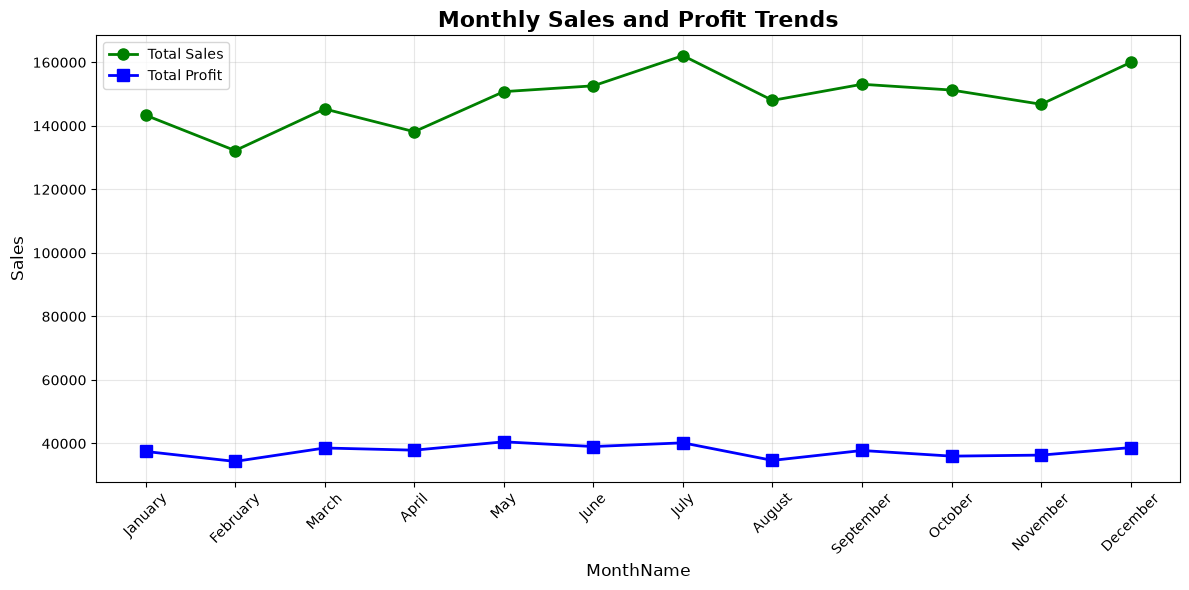

In [12]:
plt.figure(figsize=(12,6))
plt.plot(
    monthly_sales["MonthName"],
    monthly_sales["Sales"],
    label="Total Sales",
    marker="o",
    linewidth=2,
    markersize=8,
    color="g"
)

plt.plot(
    monthly_sales["MonthName"],
    monthly_sales["Profit"],
    label="Total Profit",
    marker="s",
    linewidth=2,
    markersize=8,
    color="b"
   
)
plt.title("Monthly Sales and Profit Trends",fontsize=16,fontweight="bold")
plt.xlabel("MonthName",fontsize=12)
plt.ylabel("Sales",fontsize=12)
plt.grid(True,alpha=0.3)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


### Category Performance Analysis:

In [13]:
print("===CATEGORY PERFORMANCE ANALYSIS===")
category_performance=df.groupby("Category").agg({
    "Sales":"sum",
    "Profit":"sum",
    "Quantity":"sum"
}).sort_values("Sales",ascending=False)
print("Category Performance (Sorted by Sales):")
print(category_performance)

===CATEGORY PERFORMANCE ANALYSIS===
Category Performance (Sorted by Sales):
                     Sales        Profit     Quantity
Category                                             
Books        370971.872558  92304.452141  3737.000000
Electronics  363371.420635  89894.080069  3587.000000
Clothing     358178.751209  91613.246341  3697.000000
Sports       346561.413563  90849.949134  3515.215385
Home Goods   344634.290152  86993.108551  3755.000000


### Draw Bar Plot to visualize Total Sales By Category:

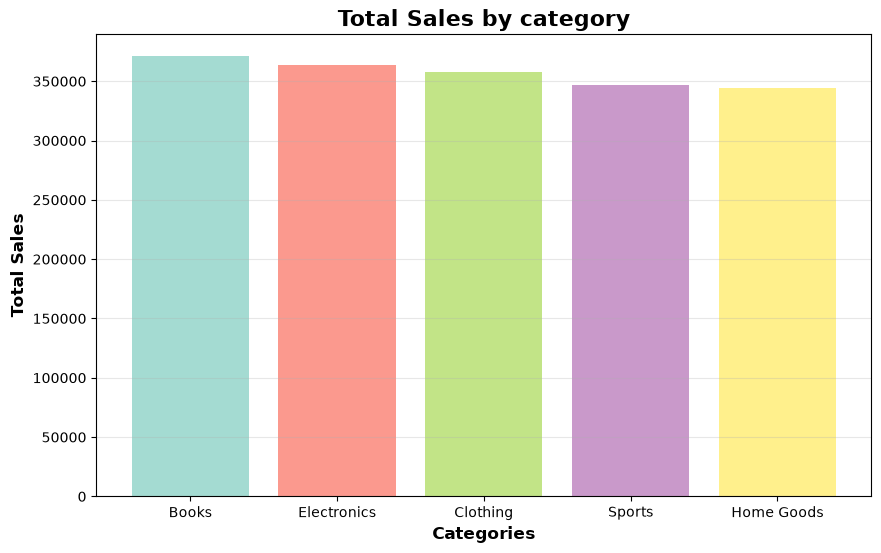

In [14]:
fig, ax=plt.subplots(figsize=(10,6))
colors=plt.cm.Set3(np.linspace(0,1,len(category_performance)))
ax.bar(category_performance.index,category_performance["Sales"],color=colors,alpha=0.8)
ax.set_title("Total Sales by category",fontsize=16,fontweight="bold")
ax.set_xlabel("Categories",fontsize=12,fontweight="bold")
ax.set_ylabel("Total Sales",fontsize=12,fontweight="bold")
plt.grid(axis="y",alpha=0.3)
plt.show()

### Regional performance Analysis:

In [15]:
print("===REGIONAL PERFORMANCE ANALYSIS===")
regional_performance=df.groupby("Region").agg({
    "Sales":["sum","mean","count"],
    "Profit":["sum","mean"]
        }).round(2)
print("Regional Performance")
print(regional_performance)

===REGIONAL PERFORMANCE ANALYSIS===
Regional Performance
            Sales                   Profit        
              sum    mean count        sum    mean
Region                                            
East    394439.34  991.05   398   98973.62  248.68
North   449292.76  976.72   460  112126.47  243.75
South   469471.28  969.98   484  118036.97  243.88
West    470514.37  986.40   477  122517.78  256.85


### Draw a Pie Chart to visualize Regional Sales Distribution:

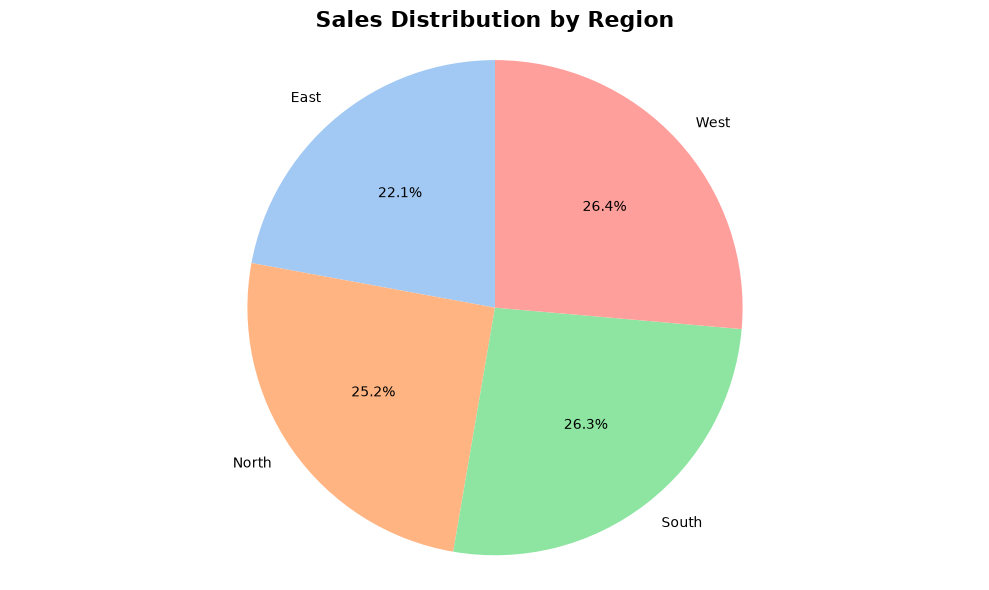

In [16]:
#Regional Sales Distribution
plt.figure(figsize=(10,6))
regional_data=df.groupby("Region")["Sales"].sum()
plt.pie(regional_data,labels=regional_data.index,colors=sns.color_palette("pastel"),startangle=90,autopct="%1.1f%%")
plt.title("Sales Distribution by Region",fontsize=16,fontweight="bold")
plt.axis("equal")
plt.tight_layout()
plt.show()

In [17]:
print("===Days of week Analysis===")
day_order=["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
df["DayOfWeek"]=pd.Categorical(df["DayOfWeek"],categories=day_order,ordered=True)
daily_performance=df.groupby("DayOfWeek").agg({
    "Sales":"mean",
    "Profit":"mean",
    "Quantity":"mean"
}).round(2)
print("\nAverage Performance by Day of Week:")
print(daily_performance)

===Days of week Analysis===

Average Performance by Day of Week:
             Sales  Profit  Quantity
DayOfWeek                           
Monday      981.23  252.74     10.24
Tuesday     983.00  242.52     10.32
Wednesday   964.43  237.69     10.21
Thursday    966.83  237.62      9.78
Friday     1011.72  259.84      9.97
Saturday    975.95  252.59      9.66
Sunday      981.11  254.94     10.22


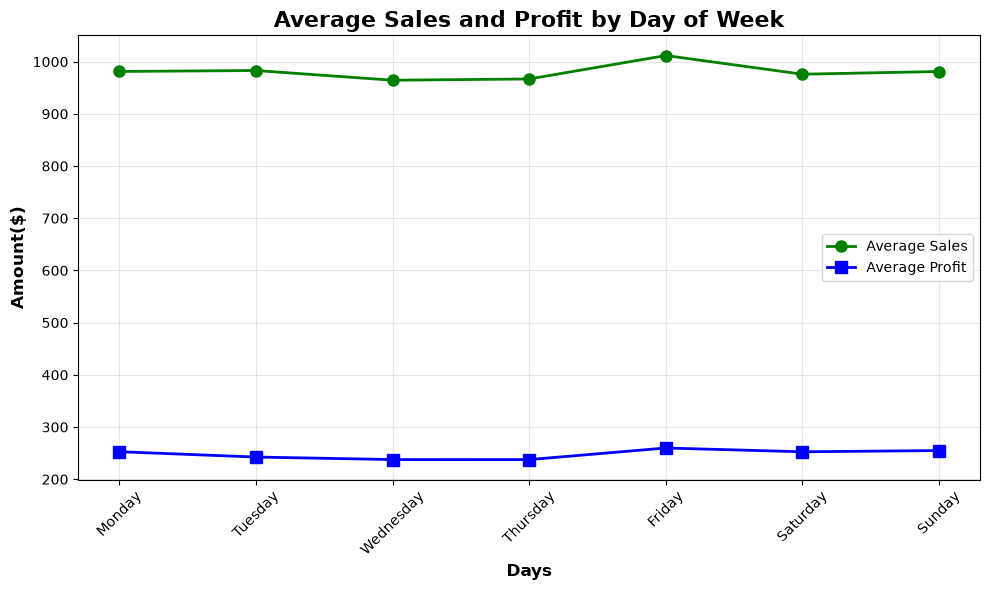

In [18]:
plt.figure(figsize=(10,6))
plt.plot(
    daily_performance.index,
    daily_performance["Sales"],
    label="Average Sales",
    marker="o",
    linewidth=2,
    markersize=8,
    color="g"
)

plt.plot(
    daily_performance.index,
    daily_performance["Profit"],
    label="Average Profit",
    marker="s",
    linewidth=2,
    markersize=8,
    color="b"
   
)
plt.title("Average Sales and Profit by Day of Week",fontsize=16,fontweight="bold")
plt.xlabel("Days",fontsize=12,fontweight="bold")
plt.ylabel("Amount($)",fontsize=12,fontweight="bold")
plt.grid(True,alpha=0.3)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


### Correlation Analysis:

In [19]:
print("====Correlation Analysis====")
numarical_df=df[["Sales","Profit","Quantity","Month"]]
correlation_matrix=numarical_df.corr()
print("Correlation Matrix:")
print(correlation_matrix)

====Correlation Analysis====
Correlation Matrix:
             Sales    Profit  Quantity     Month
Sales     1.000000  0.530753  0.054512  0.065379
Profit    0.530753  1.000000  0.028736 -0.029503
Quantity  0.054512  0.028736  1.000000  0.002608
Month     0.065379 -0.029503  0.002608  1.000000


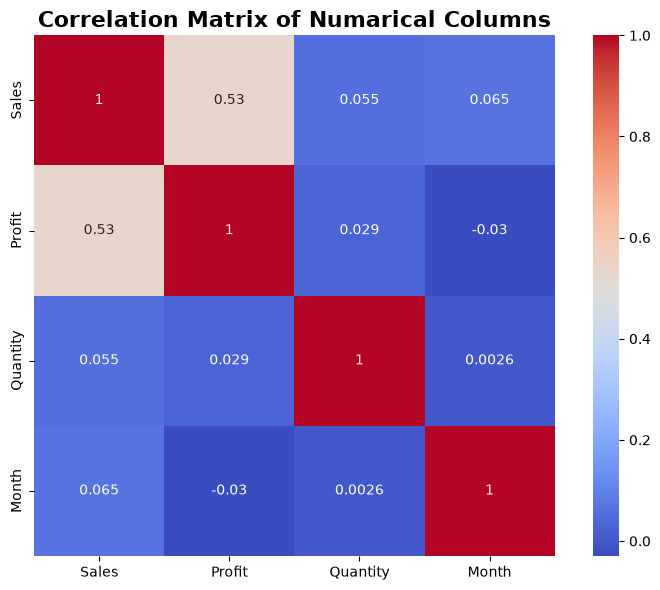

In [20]:
plt.figure(figsize=(8,6))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    square=True
    
)
plt.title("Correlation Matrix of Numarical Columns",fontsize=16,fontweight="bold")
plt.tight_layout()
plt.show()

### Data Visualization: 4 Charts Dashboard

====4-CHART RETAIL SALES DASHBOARD====


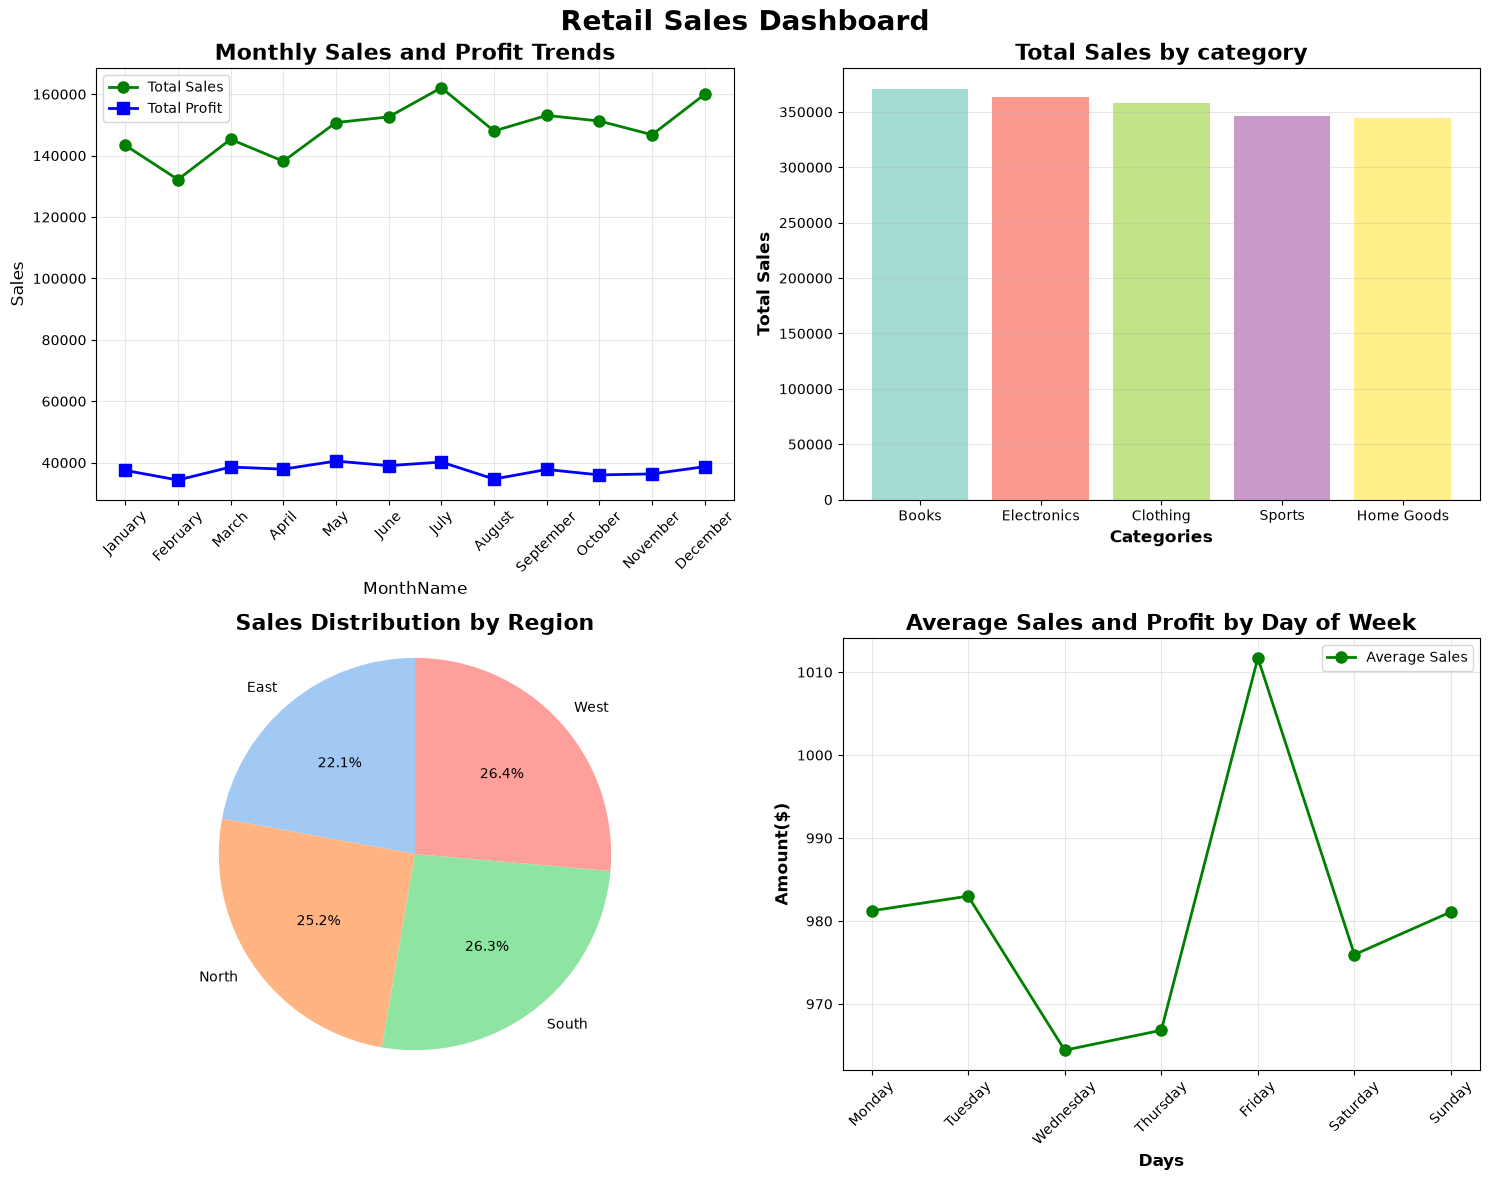

In [23]:
#4 Charts Mini Dashboard
print("====4-CHART RETAIL SALES DASHBOARD====")

#2*2 
fig, ax=plt.subplots(2,2,figsize=(15,12))
fig.suptitle("Retail Sales Dashboard",fontsize=20,fontweight="bold")

#Chart 1

ax[0,0].plot(
    monthly_sales["MonthName"],
    monthly_sales["Sales"],
    label="Total Sales",
    marker="o",
    linewidth=2,
    markersize=8,
    color="g"
)

ax[0,0].plot(
    monthly_sales["MonthName"],
    monthly_sales["Profit"],
    label="Total Profit",
    marker="s",
    linewidth=2,
    markersize=8,
    color="b"
   
)
ax[0,0].set_title("Monthly Sales and Profit Trends",fontsize=16,fontweight="bold")
ax[0,0].set_xlabel("MonthName",fontsize=12)
ax[0,0].set_ylabel("Sales",fontsize=12)
ax[0,0].grid(True,alpha=0.3)
ax[0,0].tick_params(axis='x', rotation=45)
ax[0,0].legend()




#Chart 2:

colors=plt.cm.Set3(np.linspace(0,1,len(category_performance)))
ax[0,1].bar(category_performance.index,category_performance["Sales"],color=colors,alpha=0.8)
ax[0,1].set_title("Total Sales by category",fontsize=16,fontweight="bold")
ax[0,1].set_xlabel("Categories",fontsize=12,fontweight="bold")
ax[0,1].set_ylabel("Total Sales",fontsize=12,fontweight="bold")
ax[0,1].grid(axis="y",alpha=0.3)


#Chart 3:


regional_data=df.groupby("Region")["Sales"].sum()
ax[1,0].pie(regional_data,labels=regional_data.index,colors=sns.color_palette("pastel"),startangle=90,autopct="%1.1f%%")
ax[1,0].set_title("Sales Distribution by Region",fontsize=16,fontweight="bold")
ax[1,0].axis("equal")



#Chart 4:

ax[1,1].plot(
    daily_performance.index,
    daily_performance["Sales"],
    label="Average Sales",
    marker="o",
    linewidth=2,
    markersize=8,
    color="g"
)
ax[1,1].set_title("Average Sales and Profit by Day of Week",fontsize=16,fontweight="bold")
ax[1,1].set_xlabel("Days",fontsize=12,fontweight="bold")
ax[1,1].set_ylabel("Amount($)",fontsize=12,fontweight="bold")
ax[1,1].grid(True,alpha=0.3)
ax[1,1].tick_params(axis='x', rotation=45)
ax[1,1].legend()


plt.tight_layout()
plt.show()



In [30]:
#key insights and Business Recommendations
print("==== KEY INSIGHTS AND RECOMMENDATIONS ====")

print("\n🔑 KEY FINDINGS:")
print("1. Top Performing Category:", category_performance.index[0])
print("2. Best Performing Region:",regional_data.idxmax())
print("3. Highest Sales Month:",monthly_sales.loc[monthly_sales["Sales"].idxmax(),"MonthName"])
print("4. Best Day  of Week:",daily_performance["Sales"].idxmax())
print("5. Total Annual Sales: ${:,.2f}".format(df["Sales"].sum()))
print("6. Total Annual Profit: ${:,.2f}".format(df["Profit"].sum()))

print("\n📈 BUSINESS RECOMMENDATIONS:")
print("1. Focus marketing efforts on",category_performance.index[0] ,"category")
print("2. Investigate performance in lower-perfoming regions")
print("3. Plan promotions around", daily_performance["Sales"].idxmax(), "to maximize sales")
print("4. Allocate inventory based on monthly trend patterns")
print("5. Monitor correlation between quantity and profit for pricing strategy")

print("\n📊 PROFITABILITY ANALYSIS:")
profit_margin=(df["Profit"].sum()/df["Sales"].sum())*100
print(f"Overall Profit Margin: {profit_margin:.2f}%")




==== KEY INSIGHTS AND RECOMMENDATIONS ====

🔑 KEY FINDINGS:
1. Top Performing Category: Books
2. Best Performing Region: West
3. Highest Sales Month: July
4. Best Day  of Week: Friday
5. Total Annual Sales: $1,783,717.75
6. Total Annual Profit: $451,654.84

📈 BUSINESS RECOMMENDATIONS:
1. Focus marketing efforts on Books category
2. Investigate performance in lower-perfoming regions
3. Plan promotions around Friday to maximize sales
4. Allocate inventory based on monthly trend patterns
5. Monitor correlation between quantity and profit for pricing strategy

📊 PROFITABILITY ANALYSIS:
Overall Profit Margin: 25.32%
